In [13]:
# ==========================================
# Phase 1 - Standard Python Workflow
# (Use in Every Data Analytics Project)
# ==========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load Dataset
df = pd.read_csv("Results.csv")

# 3. View First 5 Rows
df.head()

# 4. View Last 5 Rows
df.tail()

# 5. Check Dataset Information
df.info()

# 6. Check Data Types
df.dtypes

# 7. Check Dataset Shape
df.shape

# 8. Check Column Names
df.columns

# 9. Basic Statistics
df.describe()

# 10. Check Missing Values
df.isnull().sum()

# 11. Remove Duplicates
df.drop_duplicates(inplace=True)

# 12. Check Duplicate Rows
df.duplicated().sum()

# 13. Fill Missing Values
df.fillna(method="ffill", inplace=True)

# 14. Convert Date Column
df["date_added"] = pd.to_datetime(df["date_added"])

# 15. Create Month Column
df["Month"] = df["date_added"].dt.to_period("M")

# 16. Correlation Analysis
df.select_dtypes(include="number").corr()

# 17. Export Clean Dataset
df.to_csv("clean_dataset.csv", index=False)

print("Phase 1 Completed Successfully!")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   show_id                 8807 non-null   object 
 1   type                    8807 non-null   object 
 2   title                   8807 non-null   object 
 3   director                6173 non-null   object 
 4   cast                    7982 non-null   object 
 5   country                 7976 non-null   object 
 6   date_added              8709 non-null   object 
 7   release_year            8807 non-null   int64  
 8   rating                  8803 non-null   object 
 9   duration                8804 non-null   object 
 10  genre                   8807 non-null   object 
 11  description             8807 non-null   object 
 12  Added_Month             8709 non-null   object 
 13  Added_Year              8709 non-null   float64
 14  Movie_Duration_Minutes  6128 non-null   

C:\Users\Fast Computers\AppData\Local\Temp\ipykernel_2832\3368183531.py:45: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


Phase 1 Completed Successfully!


Average Movie Duration: 99.5690048939641


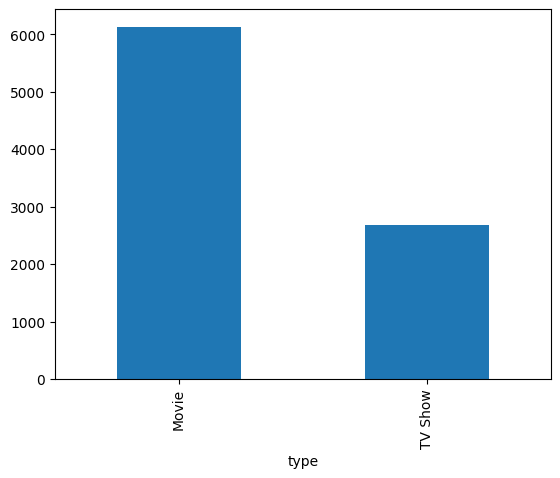

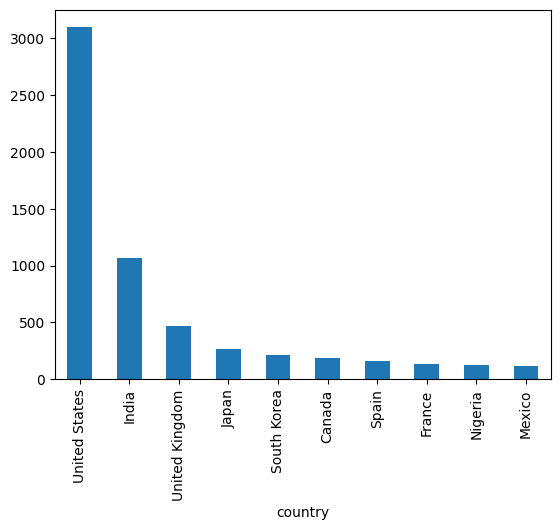

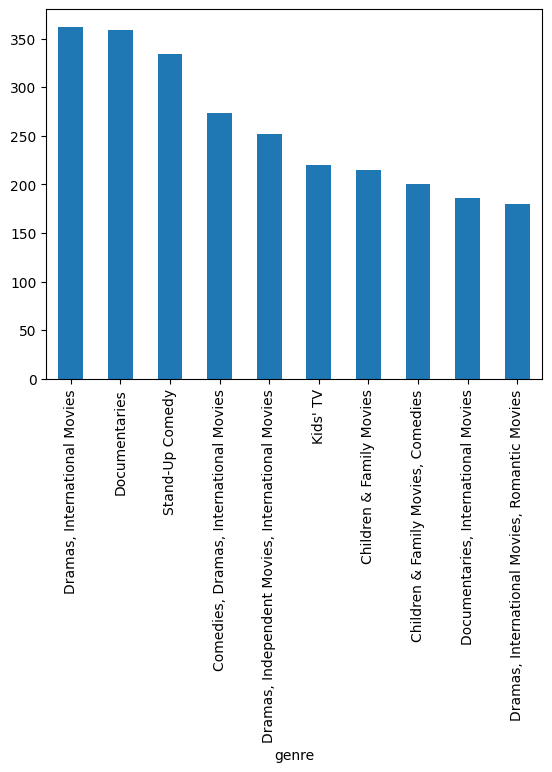

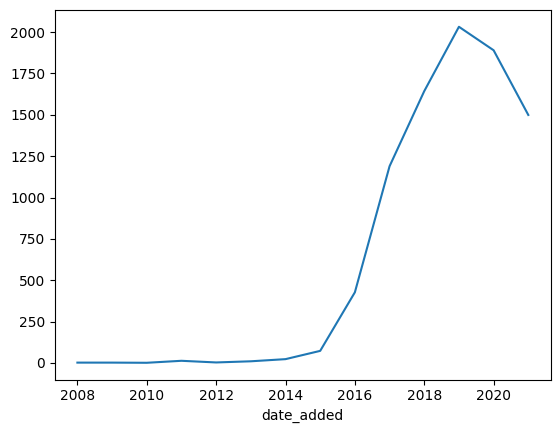

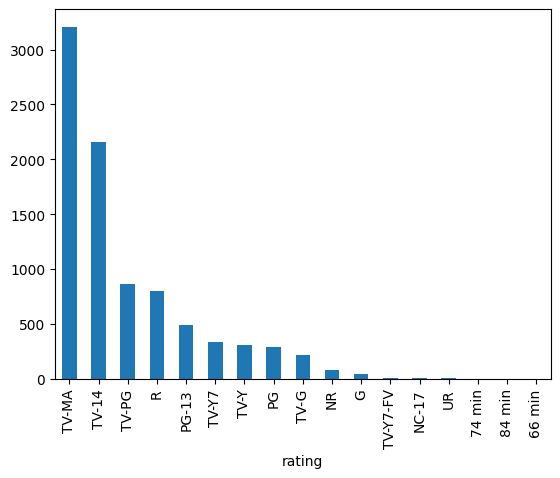

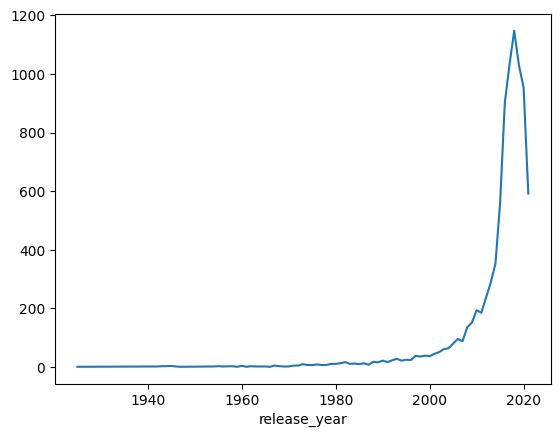

   release_year  Predicted_Content
0          2026         411.016135
1          2027         417.899917
2          2028         424.783700
3          2029         431.667483
4          2030         438.551265
Netflix Project Completed Successfully!


In [18]:
# ==========================================
# Netflix Content Analyzer Project
# Phase 2 - Business Analysis (Python)
# ==========================================

# 1. Movies vs TV Shows
df["type"].value_counts()

# 2. Top 10 Countries
top_countries = df["country"].value_counts().head(10)

# 3. Top 10 Genres
top_genre = df["genre"].value_counts().head(10)

# 4. Content Added Per Year
df["date_added"] = pd.to_datetime(df["date_added"])
content_by_year = df.groupby(df["date_added"].dt.year).size()

# 5. Rating Analysis
rating_analysis = df["rating"].value_counts()

# 6. Top 10 Directors
top_directors = df["director"].value_counts().head(10)

# 7. Top 10 Actors
top_actors = df["cast"].value_counts().head(10)

# 8. Average Movie Duration
# 8. Average Movie Duration

movies = df[df["type"] == "Movie"].copy()

movies["Movie_Duration_Minutes"] = pd.to_numeric(
    movies["duration"].str.replace(" min", "", regex=False),
    errors="coerce"
)

average_Movie_Duration_Minutes = movies["Movie_Duration_Minutes"].mean()

print("Average Movie Duration:", average_Movie_Duration_Minutes)
# 9. Release Year Analysis
release_year = df.groupby("release_year").size()

# 10. Content by Decade
df["Decade"] = (df["release_year"]//10)*10
decade_analysis = df.groupby("Decade").size()

# ==========================================
# Visualization
# ==========================================

# Movies vs TV Shows
df["type"].value_counts().plot(kind="bar")
plt.show()

# Top Countries
top_countries.plot(kind="bar")
plt.show()

# Top Genres
top_genre.plot(kind="bar")
plt.show()

# Content Added Per Year
content_by_year.plot(kind="line")
plt.show()

# Rating Distribution
rating_analysis.plot(kind="bar")
plt.show()

# Release Year Trend
release_year.plot(kind="line")
plt.show()

# ==========================================
# Future Prediction (Forecasting)
# ==========================================

from sklearn.linear_model import LinearRegression

forecast = (
    df.groupby("release_year")
      .size()
      .reset_index(name="Content_Count")
)

X = forecast[["release_year"]]
y = forecast["Content_Count"]

model = LinearRegression()
model.fit(X, y)

future_years = pd.DataFrame({
    "release_year":[2026,2027,2028,2029,2030]
})

future_years["Predicted_Content"] = model.predict(future_years)

print(future_years)

# ==========================================
# Export Final Dataset
# ==========================================

df.to_csv("final_netflix_dashboard_data.csv", index=False)

print("Netflix Project Completed Successfully!")
